# 06 - Feature Engineering

## Proyecto
Detección de Sitios Web Fraudulentos (Phishing)

## Objetivo de esta notebook
Crear nuevas variables derivadas a partir de las existentes para enriquecer la representación del problema:
- features de suma de señales por grupo de riesgo
- features de conteo de indicadores sospechosos
- features de interacción entre variables de alta correlación
- documentación de cada feature con su hipótesis de utilidad

Esta notebook corresponde al backlog item **PB-08: Realizar feature engineering**.

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga del dataset intermedio (post-limpieza)

In [2]:
df = pd.read_csv("../data/interim/dataset_clean.csv")
print(f"Dimensiones del dataset limpio: {df.shape}")
df.head()

Dimensiones del dataset limpio: (5849, 31)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## Contexto del feature engineering

El dataset de phishing contiene variables ternarias {-1, 0, 1} organizadas en grupos temáticos:

| Grupo | Variables representativas |
|---|---|
| **URL** | `having_IP_Address`, `URL_Length`, `Shortining_Service`, `having_At_Symbol`, `double_slash_redirecting`, `Prefix_Suffix`, `having_Sub_Domain` |
| **Seguridad/Dominio** | `SSLfinal_State`, `Domain_registeration_length`, `age_of_domain`, `DNSRecord`, `Favicon`, `HTTPS_token` |
| **Contenido Web** | `Request_URL`, `URL_of_Anchor`, `Links_in_tags`, `SFH`, `Submitting_to_email`, `Redirect`, `on_mouseover`, `RightClick`, `popUpWidnow`, `Iframe` |
| **Popularidad** | `web_traffic`, `Google_Index`, `Page_Rank`, `Links_pointing_to_page`, `Statistical_report` |

**Hipótesis general**: las features derivadas que combinan señales de múltiples variables del mismo grupo pueden capturar patrones más robustos que las variables individuales.

In [3]:
# Definición de grupos de variables por categoría temática
url_features = [
    "having_IP_Address", "URL_Length", "Shortining_Service",
    "having_At_Symbol", "double_slash_redirecting", "Prefix_Suffix", "having_Sub_Domain"
]

security_features = [
    "SSLfinal_State", "Domain_registeration_length", "age_of_domain",
    "DNSRecord", "Favicon", "HTTPS_token"
]

content_features = [
    "Request_URL", "URL_of_Anchor", "Links_in_tags", "SFH",
    "Submitting_to_email", "Redirect", "on_mouseover",
    "RightClick", "popUpWidnow", "Iframe"
]

popularity_features = [
    "web_traffic", "Google_Index", "Page_Rank",
    "Links_pointing_to_page", "Statistical_report"
]

# Filtrar solo las que existen en el dataset
all_cols = df.columns.tolist()
url_features = [c for c in url_features if c in all_cols]
security_features = [c for c in security_features if c in all_cols]
content_features = [c for c in content_features if c in all_cols]
popularity_features = [c for c in popularity_features if c in all_cols]

print(f"URL features disponibles: {len(url_features)} -> {url_features}")
print(f"Security features disponibles: {len(security_features)} -> {security_features}")
print(f"Content features disponibles: {len(content_features)} -> {content_features}")
print(f"Popularity features disponibles: {len(popularity_features)} -> {popularity_features}")

URL features disponibles: 7 -> ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain']
Security features disponibles: 6 -> ['SSLfinal_State', 'Domain_registeration_length', 'age_of_domain', 'DNSRecord', 'Favicon', 'HTTPS_token']
Content features disponibles: 10 -> ['Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe']
Popularity features disponibles: 5 -> ['web_traffic', 'Google_Index', 'Page_Rank', 'Links_pointing_to_page', 'Statistical_report']


## Feature 1: Puntaje de riesgo por URL

**Nombre**: `url_risk_score`  
**Cálculo**: suma de señales negativas (valor -1) en las variables del grupo URL.  
**Hipótesis**: un sitio de phishing tiende a acumular múltiples indicadores sospechosos en la estructura de su URL. Una suma alta de señales negativas en este grupo debería distinguir mejor los sitios maliciosos.

Convención: contamos cuántas variables del grupo tienen valor -1 (sospechoso). Mayor valor = más sospechoso.

In [4]:
df_fe = df.copy()

if url_features:
    df_fe["url_risk_score"] = (df_fe[url_features] == -1).sum(axis=1)
    print("url_risk_score - distribución:")
    print(df_fe["url_risk_score"].value_counts().sort_index())
    print(f"\nCorrelación con Result: {df_fe['url_risk_score'].corr(df_fe['Result']):.4f}")

url_risk_score - distribución:
url_risk_score
0      52
1     471
2    1851
3    1978
4     910
5     388
6     170
7      29
Name: count, dtype: int64

Correlación con Result: -0.1885


## Feature 2: Puntaje de seguridad del dominio

**Nombre**: `security_score`  
**Cálculo**: suma de valores del grupo de seguridad/dominio (mayor valor = más legítimo).  
**Hipótesis**: los sitios legítimos tienden a tener SSL válido, dominio registrado por más tiempo, DNS activo y mayor antigüedad. La suma de estas señales positivas debe correlacionar con la clase legítima.

In [5]:
if security_features:
    df_fe["security_score"] = df_fe[security_features].sum(axis=1)
    print("security_score - estadísticas:")
    print(df_fe["security_score"].describe())
    print(f"\nCorrelación con Result: {df_fe['security_score'].corr(df_fe['Result']):.4f}")

security_score - estadísticas:
count    5849.000000
mean        1.575141
std         2.295434
min        -6.000000
25%         0.000000
50%         2.000000
75%         4.000000
max         6.000000
Name: security_score, dtype: float64

Correlación con Result: 0.2026


## Feature 3: Total de indicadores sospechosos

**Nombre**: `total_suspicious_count`  
**Cálculo**: número total de variables (en todos los grupos excepto `Result`) con valor -1.  
**Hipótesis**: los sitios de phishing acumulan más señales negativas en general. Este conteo global debe ser un indicador robusto del nivel total de sospecha de un sitio.

In [6]:
feature_cols = [c for c in df_fe.columns if c not in ["Result", "url_risk_score", "security_score"]]
df_fe["total_suspicious_count"] = (df_fe[feature_cols] == -1).sum(axis=1)

print("total_suspicious_count - estadísticas:")
print(df_fe["total_suspicious_count"].describe())
print(f"\nCorrelación con Result: {df_fe['total_suspicious_count'].corr(df_fe['Result']):.4f}")

total_suspicious_count - estadísticas:
count    5849.000000
mean        9.337665
std         3.661463
min         2.000000
25%         7.000000
50%         9.000000
75%        11.000000
max        25.000000
Name: total_suspicious_count, dtype: float64

Correlación con Result: -0.3280


## Feature 4: Total de indicadores legítimos

**Nombre**: `total_legitimate_count`  
**Cálculo**: número total de variables con valor 1 (indicador legítimo).  
**Hipótesis**: complementario al anterior. Un sitio con muchas señales positivas es probablemente legítimo.

In [7]:
df_fe["total_legitimate_count"] = (df_fe[feature_cols] == 1).sum(axis=1)

print("total_legitimate_count - estadísticas:")
print(df_fe["total_legitimate_count"].describe())
print(f"\nCorrelación con Result: {df_fe['total_legitimate_count'].corr(df_fe['Result']):.4f}")

total_legitimate_count - estadísticas:
count    5849.000000
mean       17.567105
std         3.485997
min         4.000000
25%        16.000000
50%        18.000000
75%        20.000000
max        25.000000
Name: total_legitimate_count, dtype: float64

Correlación con Result: 0.3935


## Feature 5: Ratio neto de señales (balance legítimo - sospechoso)

**Nombre**: `net_signal_ratio`  
**Cálculo**: `total_legitimate_count - total_suspicious_count`  
**Hipótesis**: la diferencia neta entre señales positivas y negativas captura el balance general del sitio. Valores positivos indican predominio de características legítimas; valores negativos indican predominio de características sospechosas.

In [8]:
df_fe["net_signal_ratio"] = df_fe["total_legitimate_count"] - df_fe["total_suspicious_count"]

print("net_signal_ratio - estadísticas:")
print(df_fe["net_signal_ratio"].describe())
print(f"\nCorrelación con Result: {df_fe['net_signal_ratio'].corr(df_fe['Result']):.4f}")

net_signal_ratio - estadísticas:
count    5849.000000
mean        8.229441
std         7.037059
min       -21.000000
25%         5.000000
50%         9.000000
75%        13.000000
max        23.000000
Name: net_signal_ratio, dtype: float64

Correlación con Result: 0.3656


## Feature 6: Interacción SSL × Tráfico Web

**Nombre**: `ssl_traffic_interaction`  
**Cálculo**: `SSLfinal_State × web_traffic` (si ambas están disponibles)  
**Hipótesis**: un sitio con certificado SSL válido (SSLfinal_State = 1) Y con tráfico web alto (web_traffic = 1) tiene alta probabilidad de ser legítimo. La interacción captura esta conjunción de señales que individualmente ya son informativas, pero que en combinación son más discriminativas.

In [9]:
ssl_col = "SSLfinal_State" if "SSLfinal_State" in df_fe.columns else None
traffic_col = "web_traffic" if "web_traffic" in df_fe.columns else None

if ssl_col and traffic_col:
    df_fe["ssl_traffic_interaction"] = df_fe[ssl_col] * df_fe[traffic_col]
    print("ssl_traffic_interaction - distribución de valores:")
    print(df_fe["ssl_traffic_interaction"].value_counts().sort_index())
    print(f"\nCorrelación con Result: {df_fe['ssl_traffic_interaction'].corr(df_fe['Result']):.4f}")
else:
    print("Columnas SSLfinal_State o web_traffic no disponibles. Feature omitida.")

ssl_traffic_interaction - distribución de valores:
ssl_traffic_interaction
-1    1347
 0    2005
 1    2497
Name: count, dtype: int64

Correlación con Result: 0.2265


## Feature 7: Puntaje de contenido web sospechoso

**Nombre**: `content_risk_score`  
**Cálculo**: conteo de señales negativas en las variables de contenido web.  
**Hipótesis**: los sitios de phishing manipulan el contenido web (iframes ocultos, redirects, pop-ups, deshabilitar click derecho). Un score alto en este grupo indica manipulación de comportamiento en la página.

In [10]:
if content_features:
    df_fe["content_risk_score"] = (df_fe[content_features] == -1).sum(axis=1)
    print("content_risk_score - distribución:")
    print(df_fe["content_risk_score"].value_counts().sort_index())
    print(f"\nCorrelación con Result: {df_fe['content_risk_score'].corr(df_fe['Result']):.4f}")

content_risk_score - distribución:
content_risk_score
0     446
1    1195
2    1448
3    1344
4     624
5     306
6     232
7     174
8      64
9      16
Name: count, dtype: int64

Correlación con Result: -0.3760


## Resumen de features creadas y correlaciones

In [11]:
new_features = [
    "url_risk_score", "security_score", "total_suspicious_count",
    "total_legitimate_count", "net_signal_ratio",
    "ssl_traffic_interaction", "content_risk_score"
]
new_features = [f for f in new_features if f in df_fe.columns]

correlaciones = (
    df_fe[new_features + ["Result"]]
    .corr()["Result"]
    .drop("Result")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Correlaciones de las nuevas features con Result:")
print(correlaciones.to_string())

Correlaciones de las nuevas features con Result:
total_legitimate_count     0.393488
content_risk_score        -0.376041
net_signal_ratio           0.365612
total_suspicious_count    -0.328048
ssl_traffic_interaction    0.226452
security_score             0.202618
url_risk_score            -0.188525


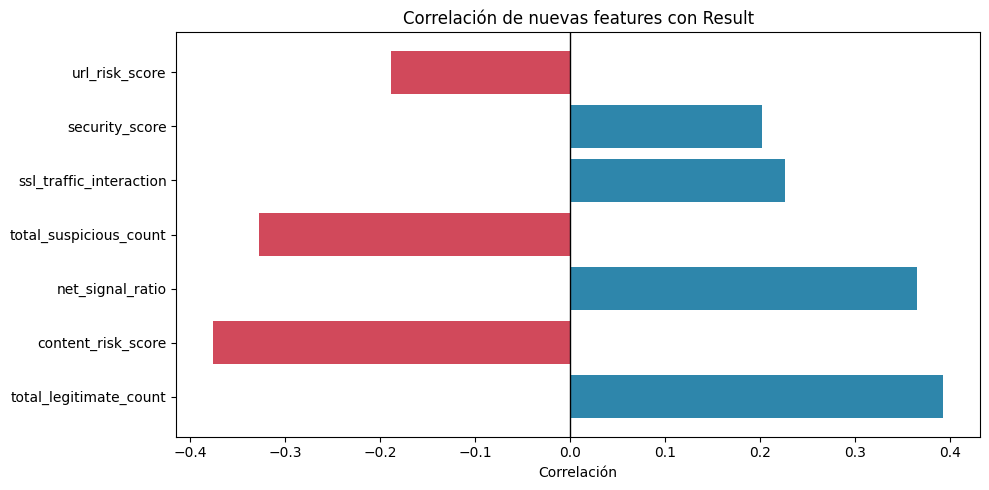

In [12]:
plt.figure(figsize=(10, 5))
colors = ["#2E86AB" if v > 0 else "#D1495B" for v in correlaciones.values]
plt.barh(correlaciones.index, correlaciones.values, color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Correlación de nuevas features con Result")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()

## Selección preliminar: eliminación de redundancia

Se verifican correlaciones altas entre las nuevas features para descartar las que sean prácticamente idénticas entre sí.

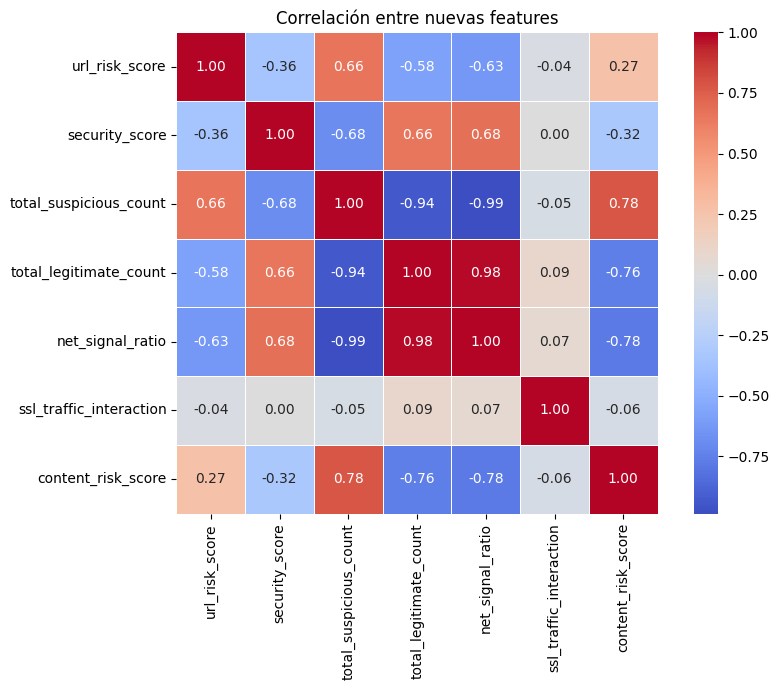

In [13]:
corr_matrix_new = df_fe[new_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix_new, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlación entre nuevas features")
plt.tight_layout()
plt.show()

In [14]:
# Identificar pares con correlación absoluta > 0.90 (altamente redundantes)
threshold = 0.90
pares_redundantes = []

for i in range(len(corr_matrix_new.columns)):
    for j in range(i+1, len(corr_matrix_new.columns)):
        val = abs(corr_matrix_new.iloc[i, j])
        if val > threshold:
            pares_redundantes.append((
                corr_matrix_new.columns[i],
                corr_matrix_new.columns[j],
                round(val, 4)
            ))

if pares_redundantes:
    print(f"Pares de features con correlación > {threshold}:")
    for p in pares_redundantes:
        print(f"  {p[0]} <-> {p[1]}: {p[2]}")
else:
    print(f"No se encontraron pares con correlación absoluta > {threshold}. Todas las features son suficientemente distintas.")

Pares de features con correlación > 0.9:
  total_suspicious_count <-> total_legitimate_count: 0.9387
  total_suspicious_count <-> net_signal_ratio: 0.9853
  total_legitimate_count <-> net_signal_ratio: 0.9838


## Guardado del dataset con features nuevas

In [15]:
df_fe.to_csv("../data/interim/dataset_features.csv", index=False)
print(f"Dataset con features guardado en ../data/interim/dataset_features.csv")
print(f"Shape original: {df.shape}")
print(f"Shape con features nuevas: {df_fe.shape}")
print(f"Features nuevas añadidas: {new_features}")

Dataset con features guardado en ../data/interim/dataset_features.csv
Shape original: (5849, 31)
Shape con features nuevas: (5849, 38)
Features nuevas añadidas: ['url_risk_score', 'security_score', 'total_suspicious_count', 'total_legitimate_count', 'net_signal_ratio', 'ssl_traffic_interaction', 'content_risk_score']


## Resumen de PB-08

| Feature | Cálculo | Hipótesis |
|---|---|---|
| `url_risk_score` | Conteo de -1 en grupo URL | Phishing acumula señales sospechosas en URL |
| `security_score` | Suma del grupo de seguridad/dominio | Legítimo tiene más señales de seguridad válidas |
| `total_suspicious_count` | Conteo global de -1 | Phishing tiene más indicadores negativos en total |
| `total_legitimate_count` | Conteo global de 1 | Legítimo tiene más indicadores positivos en total |
| `net_signal_ratio` | Legítimo - Sospechoso | Balance neto entre señales positivas y negativas |
| `ssl_traffic_interaction` | SSL × Tráfico | Conjunción de SSL válido y tráfico alto indica legitimidad |
| `content_risk_score` | Conteo de -1 en contenido web | Phishing manipula el comportamiento de la página |

Esta notebook corresponde al backlog item **PB-08: Realizar feature engineering**.